In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


In [ ]:
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

In [18]:
import glob
import re

In [19]:
csv_files = glob.glob(
    "/kaggle/input/**/*.csv",
    recursive=True
)

In [20]:
def get_strategy_name(filename):

    name = os.path.basename(filename)

    if "router" in name.lower():
        return "Router"

    elif "tree_search" in name.lower():
        return "Tree Search"

    elif "self_consistency" in name.lower():
        return "Self-Consistency"

    elif "best_of_n" in name.lower():
        return "Best-of-N"

    elif "greedy" in name.lower():
        return "Greedy"

    else:
        return os.path.splitext(name)[0]

In [21]:
records = []

for file in csv_files:

    df = pd.read_csv(file)

    if df.empty:
        continue

    # Check required columns
    if "passed" not in df.columns:
        print(f"Skipping {os.path.basename(file)}: no 'passed' column")
        continue

    if "flops_estimated_flops" not in df.columns:
        print(
            f"Skipping {os.path.basename(file)}: "
            f"no 'flops_estimated_flops' column"
        )
        continue

    strategy = get_strategy_name(file)

    n_problems = len(df)

    pass_rate = df["passed"].astype(bool).mean()

    total_flops = df[
        "flops_estimated_flops"
    ].astype(float).sum()

    mean_flops = total_flops / n_problems

    if "flops_total_tokens" in df.columns:

        total_tokens = df[
            "flops_total_tokens"
        ].astype(float).sum()

    else:

        total_tokens = 0

    mean_tokens = total_tokens / n_problems

    records.append({

        "strategy": strategy,

        "n_problems": n_problems,

        "n_passed": int(
            df["passed"].astype(bool).sum()
        ),

        "pass_rate": pass_rate,

        "pass_rate_percent": pass_rate * 100,

        "total_flops": total_flops,

        "mean_test_time_compute_flops": mean_flops,

        "total_tokens": total_tokens,

        "mean_tokens_per_problem": mean_tokens
    })

In [22]:
summary_df = pd.DataFrame(records)

summary_df = summary_df.sort_values(
    "mean_test_time_compute_flops"
).reset_index(drop=True)

display(summary_df)

,strategy,n_problems,n_passed,pass_rate,pass_rate_percent,total_flops,mean_test_time_compute_flops,total_tokens,mean_tokens_per_problem
0,Greedy,257,140,0.544747,54.474708,1.120181e+14,4.358680e+11,36282.0,141.175097
1,Best-of-N,257,184,0.715953,71.595331,5.887263e+14,2.290764e+12,190685.0,741.964981
2,Self-Consistency,257,187,0.727626,72.762646,6.019652e+14,2.342277e+12,194973.0,758.649805
3,Router,257,191,0.743191,74.319066,6.410582e+14,2.494390e+12,176213.0,685.653696
4,Tree Search,257,139,0.540856,54.085603,9.310234e+14,3.622659e+12,74139.0,288.478599


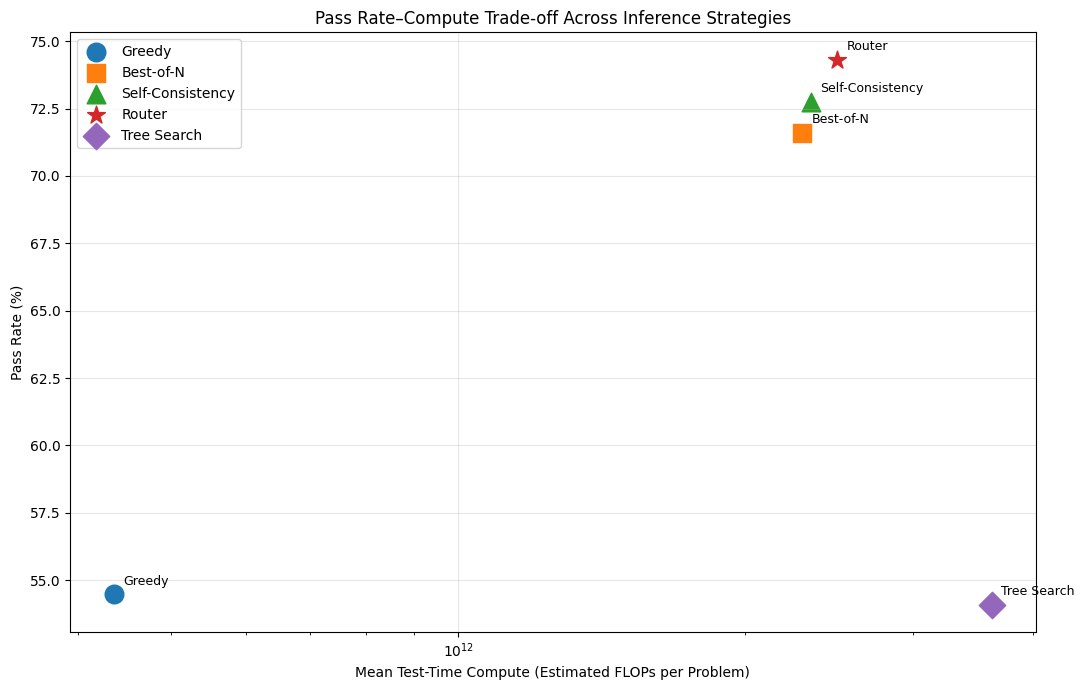

In [23]:
markers = {
    "Greedy": "o",
    "Best-of-N": "s",
    "Self-Consistency": "^",
    "Tree Search": "D",
    "Router": "*"
}

plt.figure(figsize=(11, 7))

for _, row in summary_df.iterrows():

    strategy = row["strategy"]

    marker = markers.get(strategy, "o")

    plt.scatter(
        row["mean_test_time_compute_flops"],
        row["pass_rate_percent"],
        marker=marker,
        s=180,
        label=strategy
    )

    plt.annotate(
        strategy,
        (
            row["mean_test_time_compute_flops"],
            row["pass_rate_percent"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )


plt.xscale("log")

plt.xlabel(
    "Mean Test-Time Compute (Estimated FLOPs per Problem)"
)

plt.ylabel("Pass Rate (%)")

plt.title(
    "Pass Rate–Compute Trade-off Across Inference Strategies"
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()